# Example 

In this notebook a simple case is presented in order to show the general scheme which has been followed 

In [1]:
import tensorflow.keras.backend as K
from tensorflow.keras.regularizers import l2
from hyperopt import STATUS_OK, tpe, Trials, hp, fmin
from hyperopt.pyll.stochastic import sample
from hyperopt.pyll.base import scope
from sklearn.model_selection import KFold
import numpy as np
from matplotlib import pyplot as plt
from tensorflow.keras.optimizers import Adam,Nadam,Adamax
from ann_functions import getModel, kCrossVal, transfBestparam
from time import perf_counter
import tensorflow as tf
from generalization import Neural_network, MultiFidelity

import tinyDA as tda
from scipy.stats import multivariate_normal, uniform
import arviz as az
import keras

Ray module not found. Multiprocessing features are not available


In [2]:
# For reproducibility purposes , we set the seed to a fixed number
seed = 10
tf.random.set_seed(seed)
np.random.seed(seed)
keras.utils.set_random_seed(seed)

In [3]:
# The high fidelity (true) function and the low fidelity (noisy version) function are introduced 
highfid = lambda x: np.sin(x)+0.5*np.sin(2*x)+0.3*np.sin(3*x)
lowfid=lambda x:highfid(x)+0.2*np.sin(20*x)+0.1*np.sin(10*x)+0.1*np.sin(30*x)-0.4*np.sin(3*x)


Nhf = 7 # number of points to train the High Fidelity model
Nlf = 30 # number of points to train the Low Fidelity model
N = Nhf + Nlf

# training and test data
xhf = np.linspace(0,5,Nhf)
xlf = np.linspace(0,5,Nlf)
x_test = np.linspace(0,5,1000)
Yhf = highfid(xhf)
Ylf = lowfid(xlf)

# number of epochs
NepoLF = 2000
NepoHF = 750

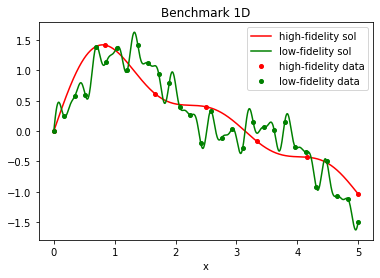

In [4]:
plt.figure()
plt.plot(x_test,highfid(x_test),'r', label = 'high-fidelity sol')
plt.plot(x_test,lowfid(x_test),'g', label = 'low-fidelity sol')
plt.plot(xhf,highfid(xhf),'ro', label = 'high-fidelity data', markersize = 4)
plt.plot(xlf,lowfid(xlf),'go', label = 'low-fidelity data', markersize = 4)
plt.xlabel('x')
plt.legend()
plt.title('Benchmark 1D')
plt.show()

The low fidelity model can be seen as a noised version of the high fidelity model. In general, the data from a low fidelity model are easier or less expensive to be obtained

# Low-fidelity model

In [5]:
bestLF_params = {'lr' : 0.0255, 'kernel_init' : 'glorot_uniform', 'opt' : 'Adam'} 
modelLF=Neural_network('LF',params=bestLF_params,data_train=xlf,output_train=Ylf,N=NepoLF,n=Nlf,train=True,do_HPO=False,verbose=False) # Neural_network is the class that contains all the informations and the functions related to a Neural Network
yLF=modelLF.prediction(x_test) # associates to x_test the correspondent prediction of y using LF model
(mse_LF,R_LF)=modelLF.performance(x_test,highfid(x_test)) # quality test of the model

Test MSE: 0.09631736770088165
R^2: 0.783431241006793


# High-fidelity model

In [6]:
bestHF_params = {'lr' : 0.0255, 'kernel_init' : 'glorot_uniform', 'opt' : 'Adam'}
modelHF=Neural_network('LF',params=bestHF_params,data_train=xhf,output_train=Yhf,N=NepoHF,n=Nhf,train=True,do_HPO=False,verbose=False)
yHF=modelHF.prediction(x_test)
(mse_HF,R_HF)=modelHF.performance(x_test,highfid(x_test)) 

Test MSE: 0.08387006883936794
R^2: 0.811418883646978


# 2 steps model 

In [7]:
bestLF_params = {'lr' : 0.0255, 'kernel_init' : 'glorot_uniform', 'opt' : 'Adam'}
best_params = {'kernel_init': 'uniform', 'l2weight': 0.00010018625799978436, 'lr': 0.07093837044166487, 'nodes': 74.0, 'opt': 'Adamax'}
N=[NepoLF,NepoHF]
n=[Nlf,Nhf]
names=['LF','2step']

params=[bestLF_params,best_params]
final_model=MultiFidelity(names,params=params,data_train_LF=xlf,output_train_LF=Ylf,data_train_HF=xhf,output_train_HF=Yhf,N=N,n=n,do_HPO=False,verbose=False) # Multifidelity connects different neural network classes, to build a multifidelity model
y_test=final_model.prediction(x_test)

input_HF = np.concatenate(
                    (x_test.reshape(-1,1),  final_model.model_list[0].prediction(x_test).reshape(-1,1)),axis=1
                ) 
(mse_MF,R_MF)=final_model.model_list[1].performance(input_HF,highfid(x_test))

Test MSE: 0.014878760345169849
R^2: 0.9665452374766127


Text(0.5, 1.0, 'High fidelity model - 2-step')

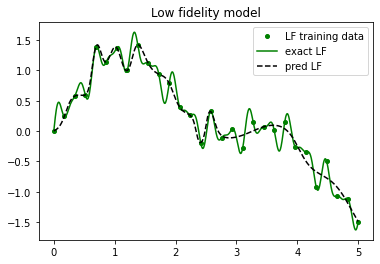

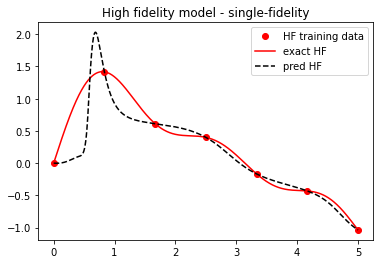

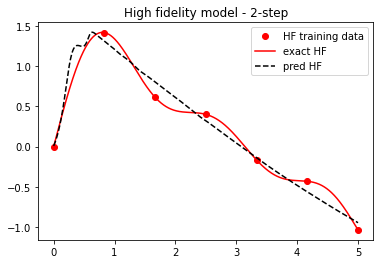

In [8]:
#LF
plt.figure()
plt.plot(xlf,Ylf,'go', label = 'LF training data', markersize = 4)
plt.plot(x_test,lowfid(x_test),'g', label = 'exact LF') 
plt.plot(x_test,yLF,'k--', label = 'pred LF')
plt.legend()
plt.title('Low fidelity model')

#HF single-fidelity
plt.figure()
plt.plot(xhf,Yhf,'ro', label = 'HF training data')
plt.plot(x_test,highfid(x_test),'-r', label = 'exact HF')
plt.plot(x_test,yHF,'--k', label = 'pred HF')
plt.legend()
plt.title('High fidelity model - single-fidelity')

#2-step MF
plt.figure()
plt.plot(xhf,Yhf,'ro', label = 'HF training data')
plt.plot(x_test,highfid(x_test),'-r', label = 'exact HF')
plt.plot(x_test,y_test,'--k', label = 'pred HF')
plt.legend()
plt.title('High fidelity model - 2-step')

It is possible to notice that the 2 steps neural network has a better approximation of the original function w.r.t. the high fidelity model alone

## Markov Chain Monte Carlo

The Markov Chain Monte Carlo method, using Metropolis Hastings algorithm, is introduced in order to associate the most probable input to the given output

In [ ]:
dim=5
real_x = np.random.rand(dim)*5
mean_prior = np.ones(dim)*2.5
cov_prior = np.ones(dim)*5*0.1  # like Manzoni paper -> 1% of the width of the ranges 
sigma=0.1
rwmh_cov = np.eye(len(real_x)) # !
rmwh_scaling = 0.1
rwmh_adaptive = False
iterations =10000
burnin = 3000
n_chains=3

# Low Fidelity model

real values are [3.85660322 0.10375975 3.16824117 3.74401941 2.49253506]
Sampling chain 1/3


Running chain, α = 0.70: 100%|██████████| 10/10 [00:00<00:00, 11.41it/s]


Sampling chain 2/3


Running chain, α = 0.80: 100%|██████████| 10/10 [00:00<00:00, 14.29it/s]


Sampling chain 3/3


Running chain, α = 0.40: 100%|██████████| 10/10 [00:00<00:00, 14.64it/s]
c:\Users\Giacomo\AppData\Local\Programs\Python\Python310\lib\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(
c:\Users\Giacomo\AppData\Local\Programs\Python\Python310\lib\site-packages\arviz\utils.py:187: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  numba_fn = numba.jit(**self.kwargs)(self.function)


estimated values are [3.163 2.371 2.885 3.293 2.333]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  3.163  0.506   2.705    3.863      0.088    0.063      33.0      33.0   
x1  2.371  0.094   2.255    2.502      0.016    0.012      33.0      33.0   
x2  2.885  0.506   2.272    3.558      0.088    0.063      33.0      33.0   
x3  3.293  0.475   2.767    3.979      0.083    0.059      33.0      33.0   
x4  2.333  0.209   2.103    2.618      0.036    0.026      33.0      24.0   

    r_hat  
x0   3.23  
x1   1.91  
x2   3.33  
x3   3.49  
x4   2.29  


c:\Users\Giacomo\AppData\Local\Programs\Python\Python310\lib\site-packages\arviz\utils.py:187: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  numba_fn = numba.jit(**self.kwargs)(self.function)


Autocorrelation...


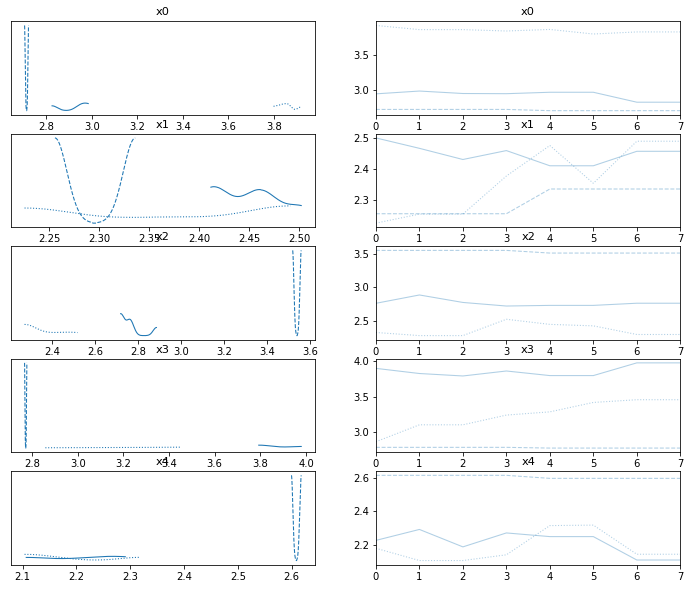

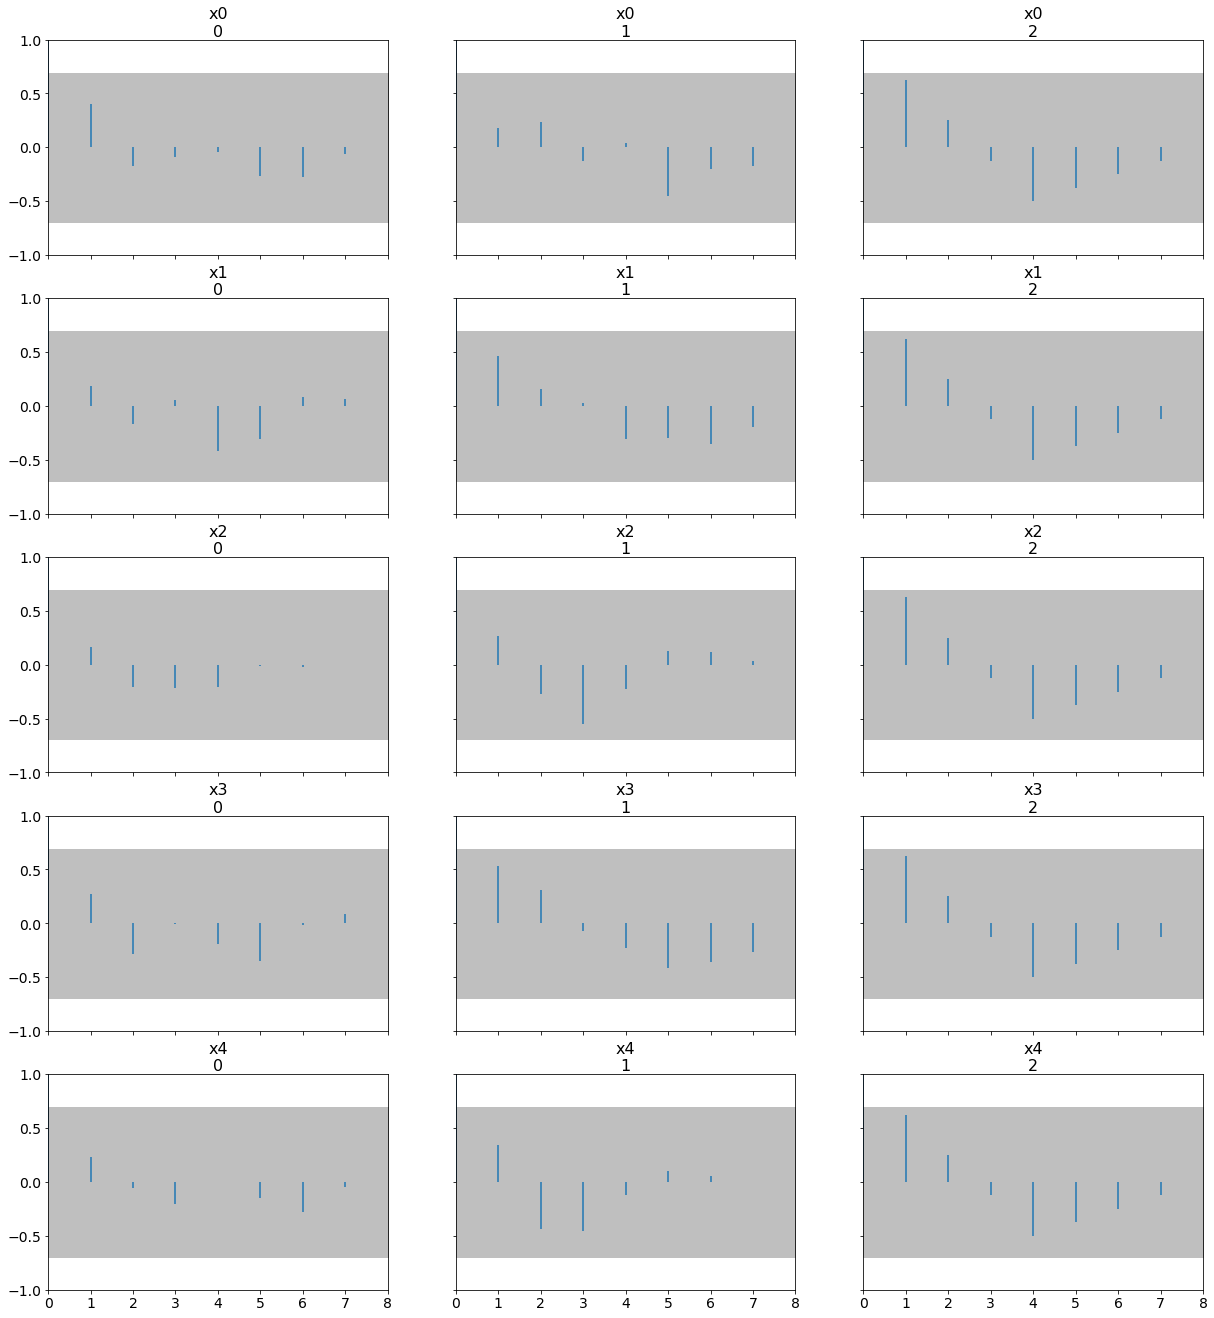

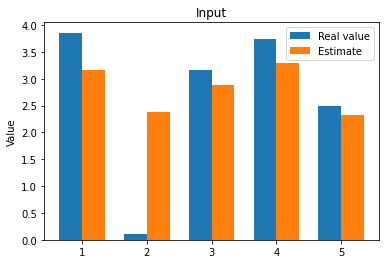

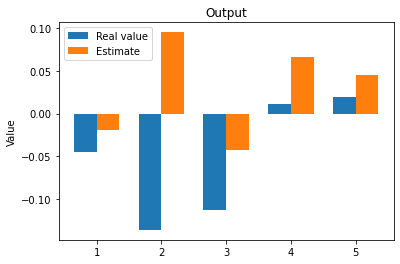

In [9]:
estimate_LF=modelLF.inverse(mean_prior, cov_prior=cov_prior, cov_noise=sigma, cov_likelihood=sigma*np.eye(real_x.shape[0]), y_obs=highfid(real_x), x_real=real_x, number_chains=n_chains, N=iterations, burn_in=burnin, diagnostic=True,rwmh_cov=rwmh_cov,rmwh_scaling=rmwh_scaling,rwmh_adaptive=rwmh_adaptive)

# High Fidelity model

real values are [3.85660322 0.10375975 3.16824117 3.74401941 2.49253506]
Sampling chain 1/3


Running chain, α = 0.80: 100%|██████████| 10/10 [00:00<00:00, 13.92it/s]


Sampling chain 2/3


Running chain, α = 0.70: 100%|██████████| 10/10 [00:00<00:00, 13.35it/s]


Sampling chain 3/3


Running chain, α = 0.70: 100%|██████████| 10/10 [00:00<00:00, 12.42it/s]
c:\Users\Giacomo\AppData\Local\Programs\Python\Python310\lib\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


estimated values are [3.101 1.807 2.168 2.888 2.945]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  3.101  0.200   2.717    3.334      0.035    0.025      33.0      33.0   
x1  1.807  0.180   1.606    2.102      0.031    0.022      33.0      33.0   
x2  2.168  0.382   1.813    2.687      0.066    0.047      33.0      33.0   
x3  2.888  0.090   2.744    3.023      0.016    0.011      33.0      24.0   
x4  2.945  0.404   2.486    3.502      0.070    0.050      33.0      33.0   

    r_hat  
x0   1.91  
x1   2.50  
x2   1.90  
x3   2.44  
x4   2.98  
Autocorrelation...


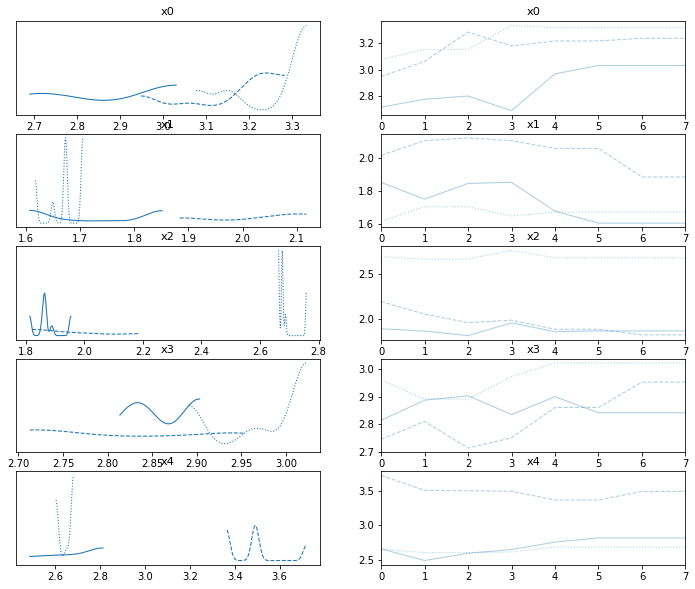

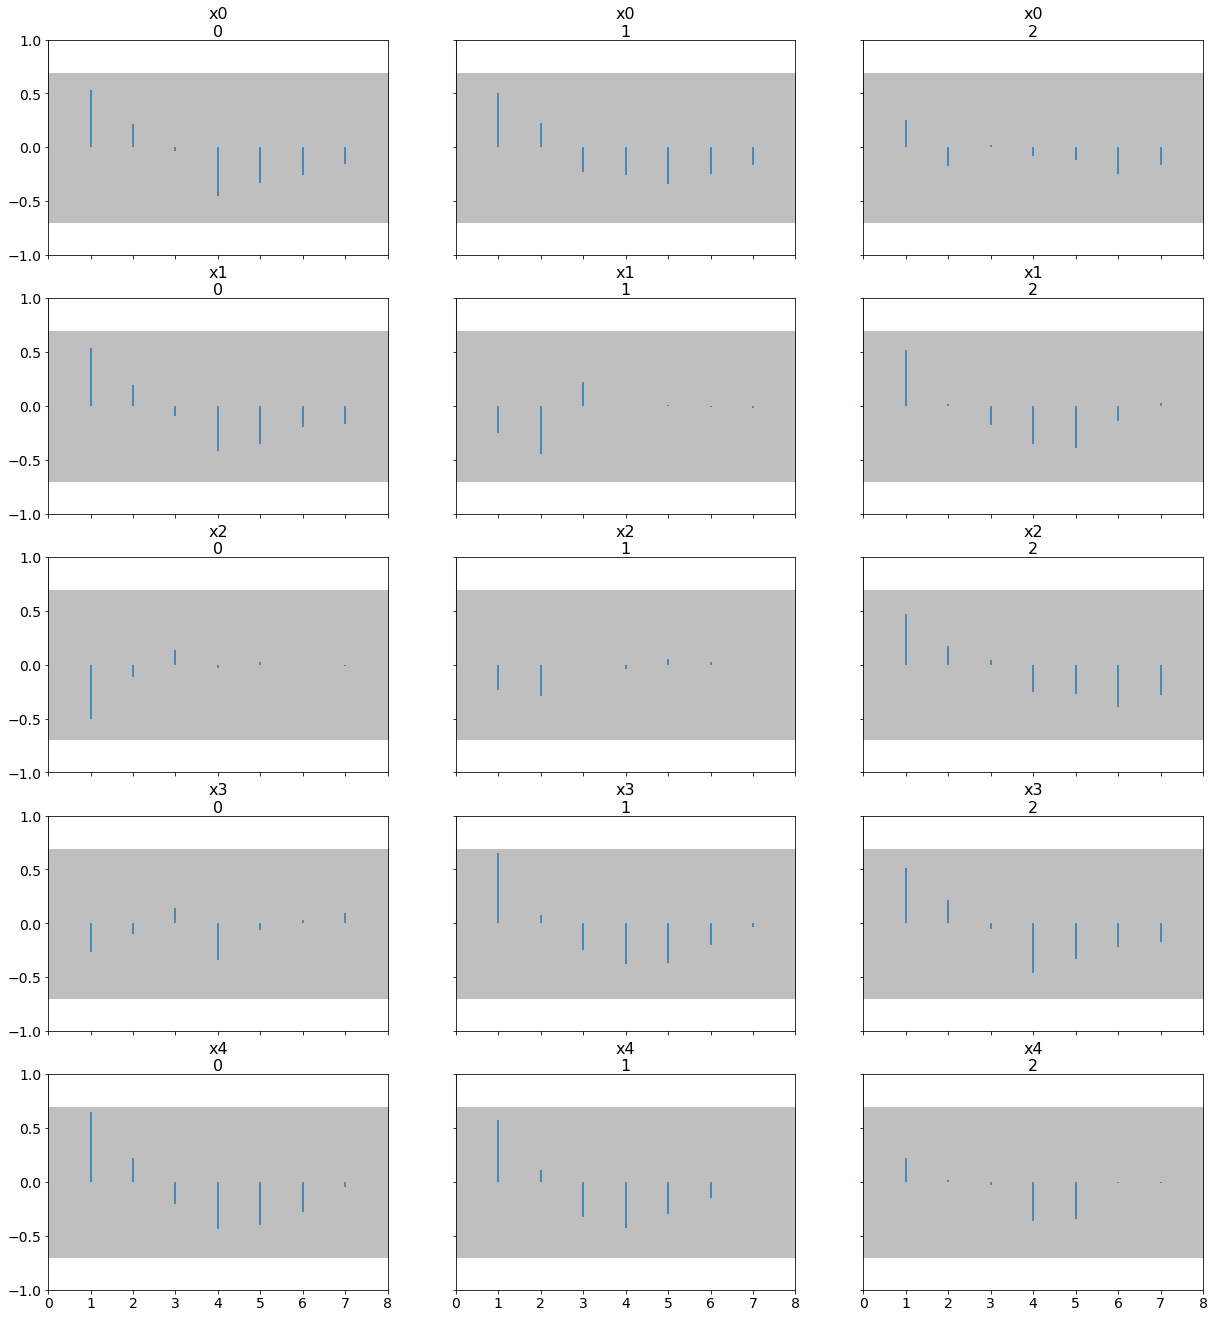

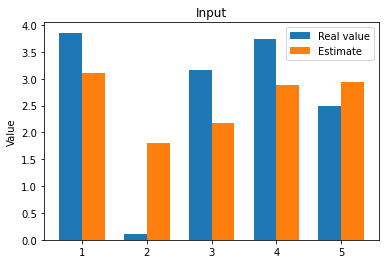

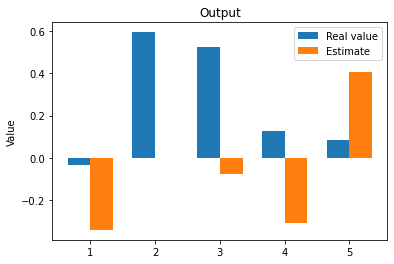

In [10]:
estimate_HF=modelHF.inverse(mean_prior, cov_prior=cov_prior, cov_noise=sigma, cov_likelihood=sigma*np.eye(real_x.shape[0]), y_obs=highfid(real_x), x_real=real_x, number_chains=n_chains, N=iterations, burn_in=burnin, diagnostic=True,rwmh_cov=rwmh_cov,rmwh_scaling=rmwh_scaling,rwmh_adaptive=rwmh_adaptive)

# Multi Fidelity model

real values are [3.85660322 0.10375975 3.16824117 3.74401941 2.49253506]
Sampling chain 1/3


Running chain, α = 0.90: 100%|██████████| 10/10 [00:01<00:00,  7.14it/s]


Sampling chain 2/3


Running chain, α = 0.60: 100%|██████████| 10/10 [00:01<00:00,  7.40it/s]


Sampling chain 3/3


Running chain, α = 0.60: 100%|██████████| 10/10 [00:01<00:00,  7.50it/s]
c:\Users\Giacomo\AppData\Local\Programs\Python\Python310\lib\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


estimated values are [2.911 2.123 3.232 2.972 3.075]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  2.911  0.760   2.002    3.854      0.132    0.094      33.0      33.0   
x1  2.123  0.212   1.851    2.480      0.037    0.026      33.0      33.0   
x2  3.232  0.781   2.480    4.474      0.136    0.097      33.0      33.0   
x3  2.972  0.338   2.521    3.381      0.059    0.042      33.0      33.0   
x4  3.075  0.756   2.467    4.178      0.131    0.094      33.0      33.0   

    r_hat  
x0   2.66  
x1   2.28  
x2   4.41  
x3   2.99  
x4   1.90  
Autocorrelation...


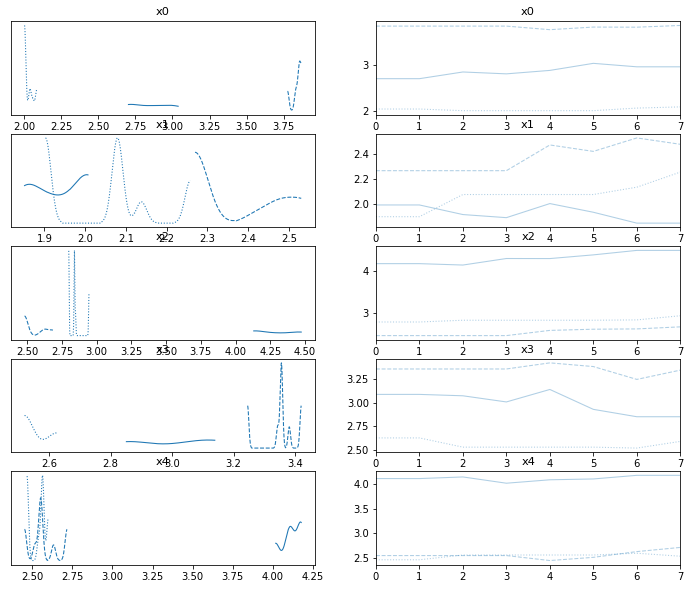

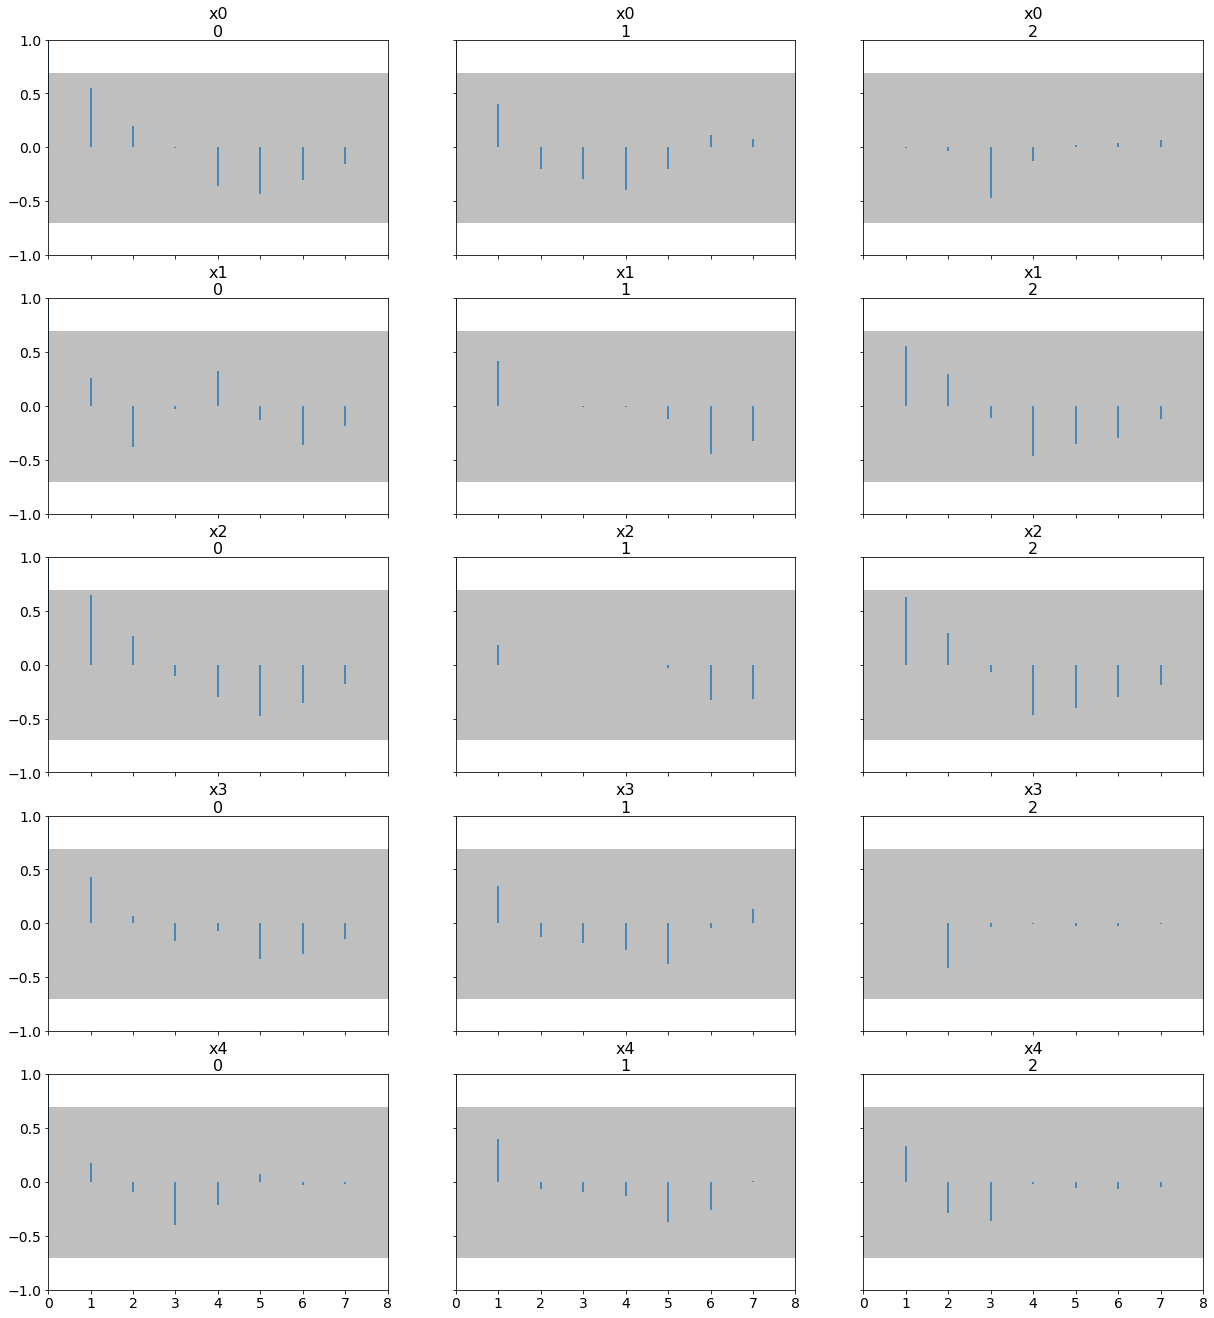

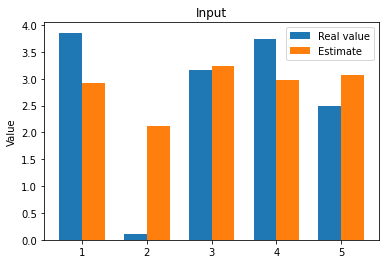

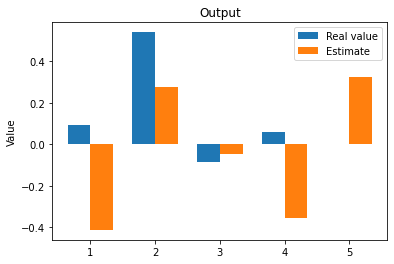

In [11]:
estimate_MF=final_model.inverse(mean_prior, cov_prior=cov_prior, cov_noise=sigma, cov_likelihood=sigma*np.eye(real_x.shape[0]), y_obs=highfid(real_x), x_real=real_x, number_chains=n_chains, N=iterations, burn_in=burnin, diagnostic=True,rwmh_cov=rwmh_cov,rmwh_scaling=rmwh_scaling,rwmh_adaptive=rwmh_adaptive)